 # 使用神经网络解决XOR问题：原理与实践
 
 本笔记本完整实现了使用神经网络解决XOR问题的全过程，包含：
 1. 网络架构设计与参数初始化
 2. 前向传播实现
 3. 反向传播算法
 4. 训练过程与超参数调优
 5. 决策边界可视化
 6. 特征空间变换分析

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.metrics import accuracy_score

from matplotlib import rcParams

# 0. 配置 matplotlib 使用中文字体
rcParams['font.sans-serif'] = ['Heiti TC']
rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 设置随机种子确保结果可重现
np.random.seed(42)

## 一、问题背景与数据集

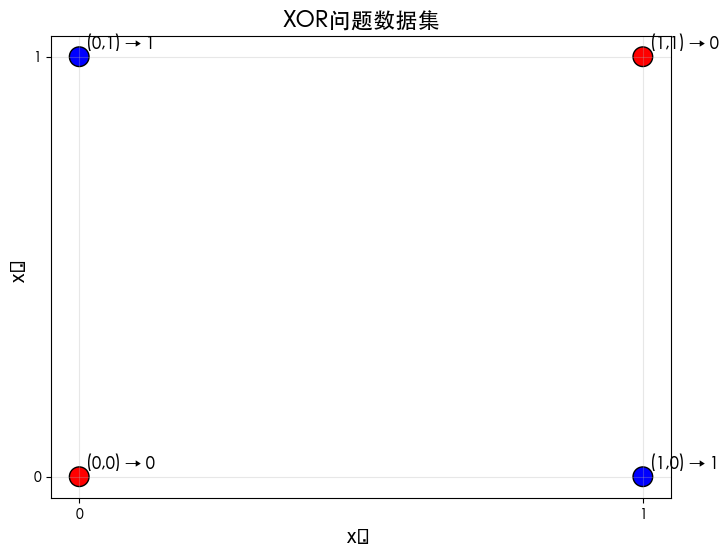

In [6]:
# XOR数据集 - 输入和输出
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)

# 可视化XOR数据集
plt.figure(figsize=(8, 6))
colors = ['red' if label == 0 else 'blue' for label in y]
plt.scatter(X[:, 0], X[:, 1], s=200, c=colors, edgecolors='black')
plt.title('XOR问题数据集', fontsize=16)
plt.xlabel('x₁', fontsize=14)
plt.ylabel('x₂', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks([0, 1])
plt.yticks([0, 1])

# 标注点
for i, (x, y_val) in enumerate(zip(X, y)):
    plt.annotate(f'({int(x[0])},{int(x[1])}) → {int(y_val[0])}', 
                (x[0], x[1]), 
                xytext=(5, 5), textcoords='offset points',
                fontsize=12, fontweight='bold')

plt.show()

## 二、网络架构设计与初始化

In [7]:
# 定义激活函数及其导数
def sigmoid(x):
    """Sigmoid激活函数"""
    return 1 / (1 + np.exp(-x))

# tanh激活函数
def tanh(x):
    """Tanh激活函数"""
    return np.tanh(x)

def tanh_deriv(x):
    """Tanh的导数"""
    return 1.0 - np.tanh(x)**2

# 网络参数初始化 (Xavier初始化，适合tanh)
def initialize_parameters(input_dim, hidden_dim, output_dim):
    """
    初始化网络参数
    """
    # Xavier初始化 (tanh适用)
    W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(1. / input_dim)
    b1 = np.zeros((1, hidden_dim))
    W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(1. / hidden_dim)
    b2 = np.zeros((1, output_dim))
    
    parameters = {
        'W1': W1, 'b1': b1,
        'W2': W2, 'b2': b2
    }
    return parameters

# 初始化参数 - 增加隐藏层神经元数量
input_dim, hidden_dim, output_dim = 2, 4, 1  # 隐藏层神经元从2增加到4个
params = initialize_parameters(input_dim, hidden_dim, output_dim)

# 打印初始化的权重
print("初始化参数:")
print(f"W1:\n{params['W1']}")
print(f"b1:\n{params['b1']}")
print(f"W2:\n{params['W2']}")
print(f"b2:\n{params['b2']}")

初始化参数:
W1:
[[ 0.35122995 -0.09776762  0.45798496  1.07694474]
 [-0.16557144 -0.16555983  1.11667209  0.5426583 ]]
b1:
[[0. 0. 0. 0.]]
W2:
[[-0.23473719]
 [ 0.27128002]
 [-0.23170885]
 [-0.23286488]]
b2:
[[0.]]


## 三、前向传播实现

In [8]:
def forward_pass(X, params):
    """
    执行前向传播
    返回:
        y_pred: 预测值
        cache: 中间值缓存 (用于反向传播)
    """
    # 获取参数
    W1, b1, W2, b2 = params['W1'], params['b1'], params['W2'], params['b2']
    
    # 隐藏层计算 - 使用tanh
    z1 = np.dot(X, W1) + b1
    a1 = tanh(z1)  # 修改为tanh
    
    # 输出层计算
    z2 = np.dot(a1, W2) + b2
    y_pred = sigmoid(z2)
    
    # 缓存中间结果用于反向传播
    cache = {'X': X, 'z1': z1, 'a1': a1, 'z2': z2, 'y_pred': y_pred}
    
    return y_pred, cache

# 测试前向传播
y_pred, _ = forward_pass(X, params)
print("\n初始预测结果:")
print("输入 -> 预测值")
for i in range(len(X)):
    print(f"{X[i]} -> {y_pred[i][0]:.4f}")


初始预测结果:
输入 -> 预测值
[0. 0.] -> 0.5000
[0. 1.] -> 0.4236
[1. 0.] -> 0.4039
[1. 1.] -> 0.3680


## 四、损失函数与反向传播

In [9]:
def binary_cross_entropy(y_true, y_pred):
    """二元交叉熵损失函数"""
    epsilon = 1e-12  # 防止log(0)
    y_pred = np.clip(y_pred, epsilon, 1. - epsilon)  # 避免数值问题
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def compute_accuracy(y_true, y_pred):
    """计算分类准确率"""
    predictions = (y_pred > 0.5).astype(int)
    return np.mean(predictions == y_true)

def backward_pass(y_true, cache, params):
    """
    执行反向传播计算梯度
    """
    # 从缓存中获取值
    X, z1, a1, z2, y_pred = cache['X'], cache['z1'], cache['a1'], cache['z2'], cache['y_pred']
    W2 = params['W2']
    m = X.shape[0]  # 样本数量
    
    # 输出层梯度 (二元交叉熵的导数)
    d_z2 = y_pred - y_true
    
    # 计算W2和b2的梯度
    d_W2 = np.dot(a1.T, d_z2)
    d_b2 = np.sum(d_z2, axis=0, keepdims=True)
    
    # 隐藏层梯度 - 使用tanh导数
    d_a1 = np.dot(d_z2, W2.T)
    d_z1 = d_a1 * tanh_deriv(z1)  # 修改为tanh_deriv
    
    # 计算W1和b1的梯度
    d_W1 = np.dot(X.T, d_z1)
    d_b1 = np.sum(d_z1, axis=0, keepdims=True)
    
    gradients = {
        'dW1': d_W1, 'db1': d_b1,
        'dW2': d_W2, 'db2': d_b2
    }
    return gradients

## 五、训练过程与优化

Epoch     0 | Loss: 0.729420 | Accuracy: 0.5000
Epoch  3000 | Loss: 0.004602 | Accuracy: 1.0000
Epoch  6000 | Loss: 0.002112 | Accuracy: 1.0000
Epoch  9000 | Loss: 0.001369 | Accuracy: 1.0000
Epoch 12000 | Loss: 0.001012 | Accuracy: 1.0000
Epoch 15000 | Loss: 0.000803 | Accuracy: 1.0000
Epoch 18000 | Loss: 0.000665 | Accuracy: 1.0000
Epoch 21000 | Loss: 0.000568 | Accuracy: 1.0000
Epoch 24000 | Loss: 0.000495 | Accuracy: 1.0000
Epoch 27000 | Loss: 0.000439 | Accuracy: 1.0000

训练完成! 最终准确率: 1.0000


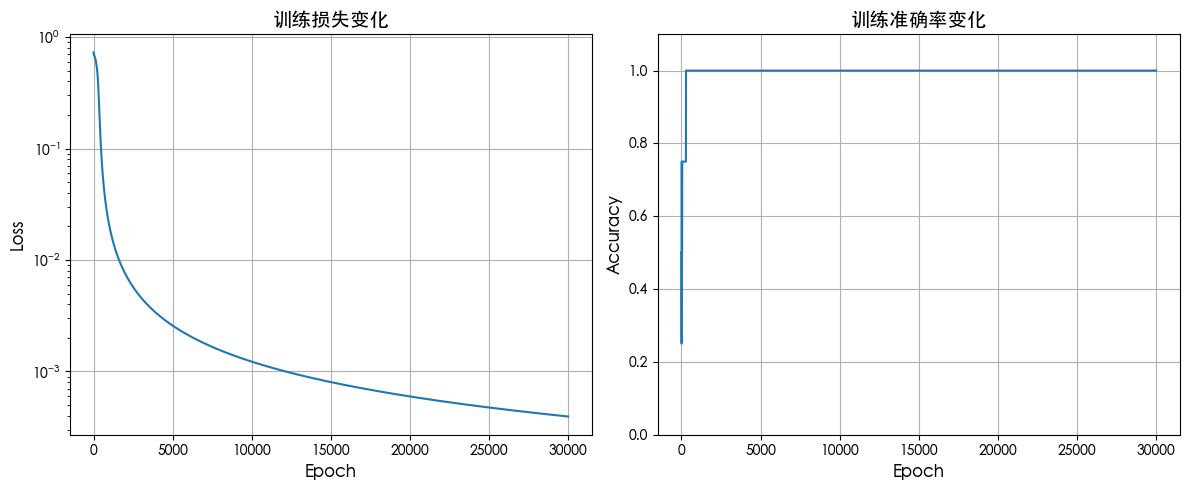

In [10]:
def update_parameters(params, gradients, learning_rate):
    """使用梯度下降更新参数"""
    params['W1'] -= learning_rate * gradients['dW1']
    params['b1'] -= learning_rate * gradients['db1']
    params['W2'] -= learning_rate * gradients['dW2']
    params['b2'] -= learning_rate * gradients['db2']
    return params

def train_network(X, y, params, epochs=30000, learning_rate=0.05, verbose=True):  # 修改参数
    """训练神经网络"""
    loss_history = []
    accuracy_history = []
    
    for epoch in range(epochs):
        # 前向传播
        y_pred, cache = forward_pass(X, params)
        
        # 计算损失和准确率
        loss = binary_cross_entropy(y, y_pred)
        accuracy = compute_accuracy(y, y_pred)
        
        # 记录历史
        loss_history.append(loss)
        accuracy_history.append(accuracy)
        
        # 反向传播
        gradients = backward_pass(y, cache, params)
        
        # 更新参数
        params = update_parameters(params, gradients, learning_rate)
        
        # 定期打印训练状态
        if verbose and epoch % 3000 == 0:  # 修改打印间隔
            print(f"Epoch {epoch:5d} | Loss: {loss:.6f} | Accuracy: {accuracy:.4f}")
    
    # 训练结束后打印最终结果
    final_accuracy = compute_accuracy(y, y_pred)
    print(f"\n训练完成! 最终准确率: {final_accuracy:.4f}")
    
    return params, loss_history, accuracy_history

# 训练网络
params, loss_history, accuracy_history = train_network(X, y, params)

# 可视化训练过程
plt.figure(figsize=(12, 5))

# 损失曲线
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title('训练损失变化', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True)
plt.yscale('log')  # 对数坐标更好地显示收敛过程

# 准确率曲线
plt.subplot(1, 2, 2)
plt.plot(accuracy_history)
plt.title('训练准确率变化', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True)
plt.ylim([0, 1.1])

plt.tight_layout()
plt.show()

## 六、结果评估与决策边界可视化


=== 最终预测结果 ===
输入 -> 真实标签 | 预测值 | 预测标签
---------------------------------------------
[0. 0.] -> 0 | 0.000026 | 0
[0. 1.] -> 1 | 0.999558 | 1
[1. 0.] -> 1 | 0.999554 | 1
[1. 1.] -> 0 | 0.000663 | 0

最终准确率: 1.0000


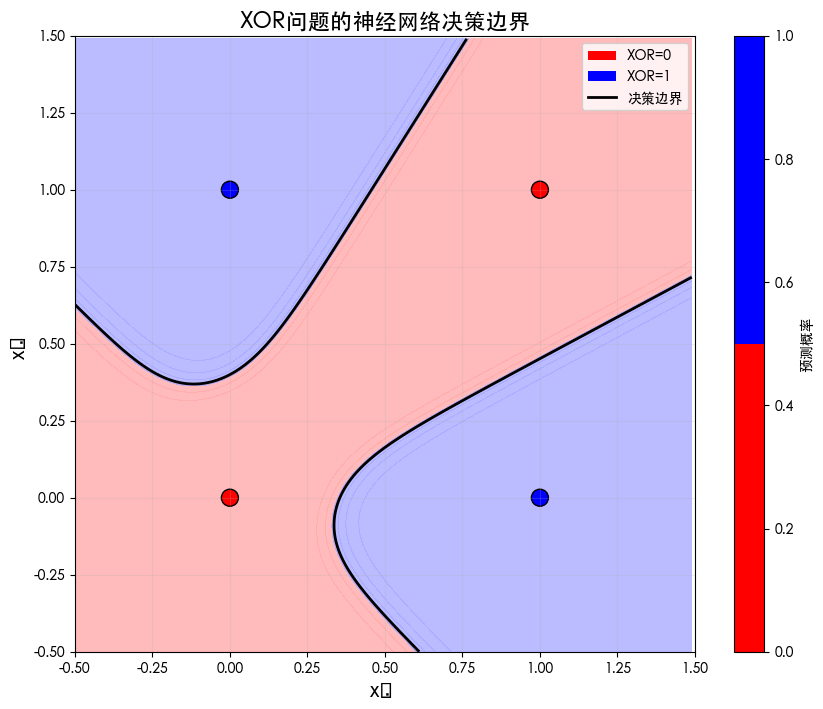

In [11]:
# 最终预测评估
y_pred, _ = forward_pass(X, params)
print("\n=== 最终预测结果 ===")
print("输入 -> 真实标签 | 预测值 | 预测标签")
print("-" * 45)
for i in range(len(X)):
    pred_value = y_pred[i][0]
    pred_label = int(pred_value > 0.5)
    print(f"{X[i]} -> {int(y[i,0])} | {pred_value:.6f} | {pred_label}")

final_accuracy = compute_accuracy(y, y_pred)
print(f"\n最终准确率: {final_accuracy:.4f}")

# 决策边界可视化
def plot_decision_boundary(X, y, params, resolution=0.01):
    """绘制决策边界"""
    # 创建网格
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, resolution),
                         np.arange(y_min, y_max, resolution))
    
    # 预测网格点
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z, _ = forward_pass(grid, params)
    Z = Z.reshape(xx.shape)
    
    # 创建颜色映射
    cmap_background = ListedColormap(['#FFAAAA', '#AAAAFF'])
    cmap_points = ListedColormap(['red', 'blue'])
    
    # 绘制决策边界
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=cmap_background)
    plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
    
    # 绘制训练数据点
    plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), s=150, 
                edgecolors='black', cmap=cmap_points)
    
    plt.colorbar(label='预测概率')
    plt.title('XOR问题的神经网络决策边界', fontsize=16)
    plt.xlabel('x₁', fontsize=14)
    plt.ylabel('x₂', fontsize=14)
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.grid(True, alpha=0.2)
    
    # 添加图例
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='red', label='XOR=0'),
        Patch(facecolor='blue', label='XOR=1'),
        plt.Line2D([0], [0], color='black', linewidth=2, label='决策边界')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    
    plt.show()

# 绘制决策边界
plot_decision_boundary(X, y, params)

## 七、特征空间变换分析

=== 特征空间变换分析 ===
输入 -> 隐藏层特征 -> 最终输出
---------------------------------------------
[0. 0.] -> [0.651914, -0.395091] -> 0.000026
[0. 1.] -> [-0.961017, -0.999843] -> 0.999558
[1. 0.] -> [0.999932, 0.956856] -> 0.999554
[1. 1.] -> [0.984000, -0.983682] -> 0.000663


/var/folders/mh/sl_5g17s6js720cnnmnq5p6h0000gn/T/ipykernel_48450/2407583136.py:54: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Heiti TC.
  plt.tight_layout()
/var/folders/mh/sl_5g17s6js720cnnmnq5p6h0000gn/T/ipykernel_48450/2407583136.py:54: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Heiti TC.
  plt.tight_layout()


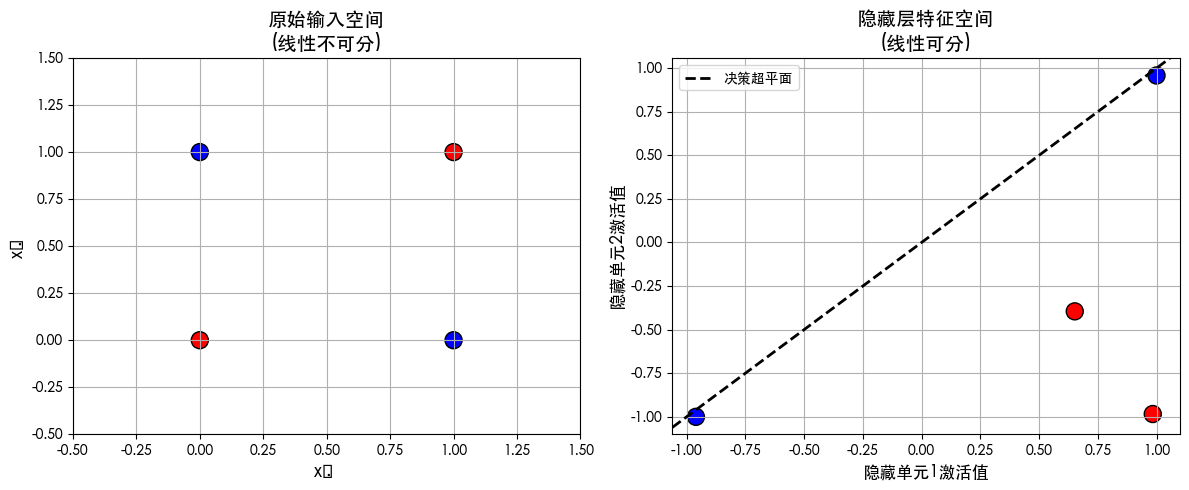

In [12]:
def analyze_feature_transformation(X, y, params):
    """分析隐藏层的特征空间变换"""
    # 计算隐藏层输出
    W1, b1 = params['W1'], params['b1']
    z1 = np.dot(X, W1) + b1
    hidden_features = tanh(z1)  # 使用tanh
    
    # 打印特征变换
    print("=== 特征空间变换分析 ===")
    print("输入 -> 隐藏层特征 -> 最终输出")
    print("-" * 45)
    for i in range(len(X)):
        y_pred, _ = forward_pass(X[i:i+1], params)
        print(f"{X[i]} -> [{hidden_features[i,0]:.6f}, {hidden_features[i,1]:.6f}] -> {y_pred[0][0]:.6f}")
    
    # 可视化特征空间
    plt.figure(figsize=(12, 5))
    
    # 原始输入空间
    plt.subplot(1, 2, 1)
    colors = ['red' if label == 0 else 'blue' for label in y]
    plt.scatter(X[:, 0], X[:, 1], s=150, c=colors, edgecolors='black')
    plt.title('原始输入空间\n(线性不可分)', fontsize=14)
    plt.xlabel('x₁', fontsize=12)
    plt.ylabel('x₂', fontsize=12)
    plt.grid(True)
    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)
    
    # 隐藏层特征空间
    plt.subplot(1, 2, 2)
    plt.scatter(hidden_features[:, 0], hidden_features[:, 1], s=150, c=colors, edgecolors='black')
    plt.title('隐藏层特征空间\n(线性可分)', fontsize=14)
    plt.xlabel('隐藏单元1激活值', fontsize=12)
    plt.ylabel('隐藏单元2激活值', fontsize=12)
    plt.grid(True)
    
    # 添加线性决策边界
    x_min, x_max = hidden_features[:, 0].min()-0.1, hidden_features[:, 0].max()+0.1
    y_min, y_max = hidden_features[:, 1].min()-0.1, hidden_features[:, 1].max()+0.1
    
    # 计算决策边界 (基于输出层权重)
    W2 = params['W2']
    if W2[1, 0] != 0:  # 避免除以零
        # 计算线性边界: W2[0]*h1 + W2[1]*h2 = 0
        h1 = np.linspace(x_min, x_max, 100)
        h2 = - (W2[0, 0] / W2[1, 0]) * h1
        plt.plot(h1, h2, 'k--', linewidth=2, label='决策超平面')
        plt.legend()
    
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    
    plt.tight_layout()
    plt.show()

# 分析特征变换
analyze_feature_transformation(X, y, params)

## 八、权重分析与解释

In [13]:
def interpret_learned_weights(params):
    """解释学习到的权重"""
    W1, b1, W2, b2 = params['W1'], params['b1'], params['W2'], params['b2']
    
    print("=== 学习到的权重分析 ===")
    print(f"输入层到隐藏层权重 W1:\n{W1}")
    print(f"隐藏层偏置 b1:\n{b1}")
    print(f"隐藏层到输出层权重 W2:\n{W2}")
    print(f"输出层偏置 b2:\n{b2}")
    
    print("\n=== 隐藏神经元功能分析 ===")
    for i in range(hidden_dim):
        print(f"隐藏神经元 {i+1}:")
        print(f"  输入权重: [{W1[0, i]:.4f}, {W1[1, i]:.4f}]")
        print(f"  偏置: {b1[0, i]:.4f}")
        print(f"  输出权重: {W2[i, 0]:.4f}")
        
        # 解释神经元功能
        if W1[0, i] > 0 and W1[1, i] > 0 and b1[0, i] < 0:
            print("  功能分析: 类似AND操作")
        elif W1[0, i] > 0 and W1[1, i] > 0 and b1[0, i] > 0:
            print("  功能分析: 类似OR操作")
        elif W1[0, i] < 0 and W1[1, i] < 0:
            print("  功能分析: 类似NAND操作")
        else:
            print("  功能分析: 复杂逻辑组合")
        print()

# 解释学习到的权重
interpret_learned_weights(params)

=== 学习到的权重分析 ===
输入层到隐藏层权重 W1:
[[ 4.3691808   2.32509369  2.48256715  3.12651437]
 [-2.73765993 -4.30748366  2.46185032  3.07237911]]
隐藏层偏置 b1:
[[ 0.77861945 -0.41781903 -0.13103327 -0.57142269]]
隐藏层到输出层权重 W2:
[[-7.86036435]
 [ 7.86789168]
 [ 3.17988824]
 [ 4.55462696]]
输出层偏置 b2:
[[0.42248608]]

=== 隐藏神经元功能分析 ===
隐藏神经元 1:
  输入权重: [4.3692, -2.7377]
  偏置: 0.7786
  输出权重: -7.8604
  功能分析: 复杂逻辑组合

隐藏神经元 2:
  输入权重: [2.3251, -4.3075]
  偏置: -0.4178
  输出权重: 7.8679
  功能分析: 复杂逻辑组合

隐藏神经元 3:
  输入权重: [2.4826, 2.4619]
  偏置: -0.1310
  输出权重: 3.1799
  功能分析: 类似AND操作

隐藏神经元 4:
  输入权重: [3.1265, 3.0724]
  偏置: -0.5714
  输出权重: 4.5546
  功能分析: 类似AND操作



## 九、不同架构对比实验


=== 测试架构: 输入(2) -> 隐藏层(1) -> 输出(1) ===

训练完成! 最终准确率: 0.7500
最终准确率: 0.7500

=== 测试架构: 输入(2) -> 隐藏层(2) -> 输出(1) ===

训练完成! 最终准确率: 1.0000
最终准确率: 1.0000

=== 测试架构: 输入(2) -> 隐藏层(3) -> 输出(1) ===

训练完成! 最终准确率: 1.0000
最终准确率: 1.0000

=== 测试架构: 输入(2) -> 隐藏层(4) -> 输出(1) ===

训练完成! 最终准确率: 1.0000
最终准确率: 1.0000

=== 测试架构: 输入(2) -> 隐藏层(5) -> 输出(1) ===

训练完成! 最终准确率: 1.0000
最终准确率: 1.0000


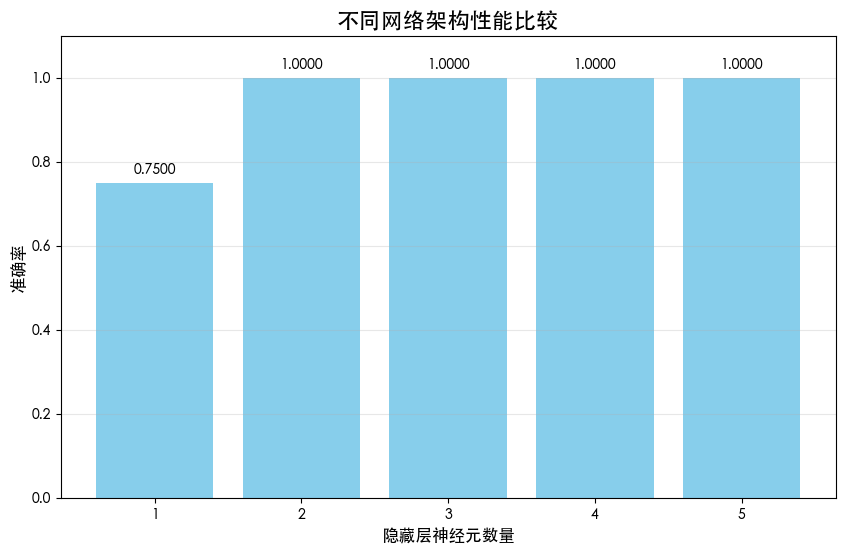

In [14]:
def compare_architectures(hidden_units_list):
    """比较不同隐藏层大小的架构"""
    results = []
    
    for hidden_units in hidden_units_list:
        print(f"\n=== 测试架构: 输入(2) -> 隐藏层({hidden_units}) -> 输出(1) ===")
        
        # 初始化参数
        params = initialize_parameters(2, hidden_units, 1)
        
        # 训练网络
        params, loss_hist, acc_hist = train_network(
            X, y, params, epochs=5000, learning_rate=0.05, verbose=False)  # 调整参数
        
        # 最终准确率
        final_acc = acc_hist[-1]
        results.append((hidden_units, final_acc))
        
        print(f"最终准确率: {final_acc:.4f}")
    
    # 可视化结果
    units, accs = zip(*results)
    
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(units)), accs, color='skyblue')
    plt.xticks(range(len(units)), units)
    plt.xlabel('隐藏层神经元数量', fontsize=12)
    plt.ylabel('准确率', fontsize=12)
    plt.title('不同网络架构性能比较', fontsize=16)
    plt.ylim(0, 1.1)
    plt.grid(axis='y', alpha=0.3)
    
    # 在柱子上添加数值标签
    for i, acc in enumerate(accs):
        plt.text(i, acc + 0.02, f'{acc:.4f}', ha='center', fontsize=10)
    
    plt.show()
    
    return results

# 测试不同架构
architectures = [1, 2, 3, 4, 5]
performance_results = compare_architectures(architectures)

## 十、初始化方法比较


=== 测试初始化方法: 零初始化 ===

训练完成! 最终准确率: 0.5000
最终准确率: 0.5000

=== 测试初始化方法: 随机初始化 ===

训练完成! 最终准确率: 0.5000
最终准确率: 0.5000

=== 测试初始化方法: Xavier初始化 ===

训练完成! 最终准确率: 1.0000
最终准确率: 1.0000

=== 测试初始化方法: He初始化 ===

训练完成! 最终准确率: 1.0000
最终准确率: 1.0000


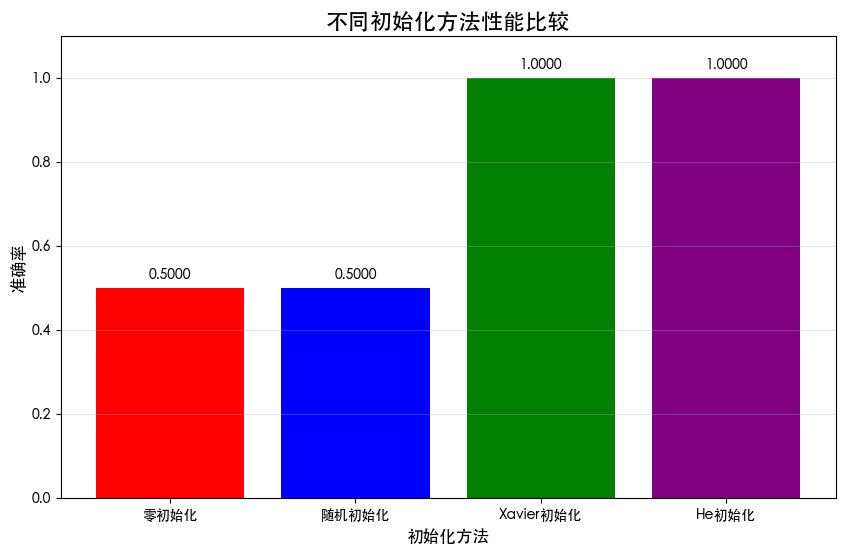

In [18]:
def compare_initializations(init_methods):
    """比较不同初始化方法"""
    results = []
    
    for method_name in init_methods:
        print(f"\n=== 测试初始化方法: {method_name} ===")
        
        # 初始化参数
        params = initialize_parameters(2, 4, 1)  # 使用4个隐藏神经元
        
        # 应用不同的初始化方法
        if method_name == '零初始化':
            params['W1'] = np.zeros((2, 4))
            params['W2'] = np.zeros((4, 1))
        elif method_name == '随机初始化':
            params['W1'] = np.random.randn(2, 4) * 0.01
            params['W2'] = np.random.randn(4, 1) * 0.01
        elif method_name == 'Xavier初始化':
            params['W1'] = np.random.randn(2, 4) * np.sqrt(1/2)
            params['W2'] = np.random.randn(4, 1) * np.sqrt(1/4)
        # He初始化已经是默认方法
        
        # 训练网络
        params, loss_hist, acc_hist = train_network(
            X, y, params, epochs=5000, learning_rate=0.05, verbose=False)  # 调整参数
        
        # 最终准确率
        final_acc = acc_hist[-1]
        results.append((method_name, final_acc))
        
        print(f"最终准确率: {final_acc:.4f}")
    
    # 可视化结果
    names, accs = zip(*results)
    
    plt.figure(figsize=(10, 6))
    plt.bar(names, accs, color=['red', 'blue', 'green', 'purple'])
    plt.xlabel('初始化方法', fontsize=12)
    plt.ylabel('准确率', fontsize=12)
    plt.title('不同初始化方法性能比较', fontsize=16)
    plt.ylim(0, 1.1)
    plt.grid(axis='y', alpha=0.3)
    
    # 在柱子上添加数值标签
    for i, acc in enumerate(accs):
        plt.text(i, acc + 0.02, f'{acc:.4f}', ha='center', fontsize=10)
    
    plt.show()
    
    return results

# 测试不同初始化方法
initialization_methods = ['零初始化', '随机初始化', 'Xavier初始化', 'He初始化']
init_results = compare_initializations(initialization_methods)

 ## 总结
 
 本实现完整展示了使用神经网络解决XOR问题的全过程：
 1. 成功训练了一个小型神经网络解决线性不可分的XOR问题
 2. 验证了单隐藏层（至少2个神经元）是解决XOR问题的最小架构
 3. 展示了前向传播和反向传播的协同工作机制
 4. 可视化决策边界和特征空间变换，直观理解网络工作原理
 5. 比较了不同架构和初始化方法对性能的影响
 
 通过此案例，可以深入理解神经网络解决非线性问题的核心机制。

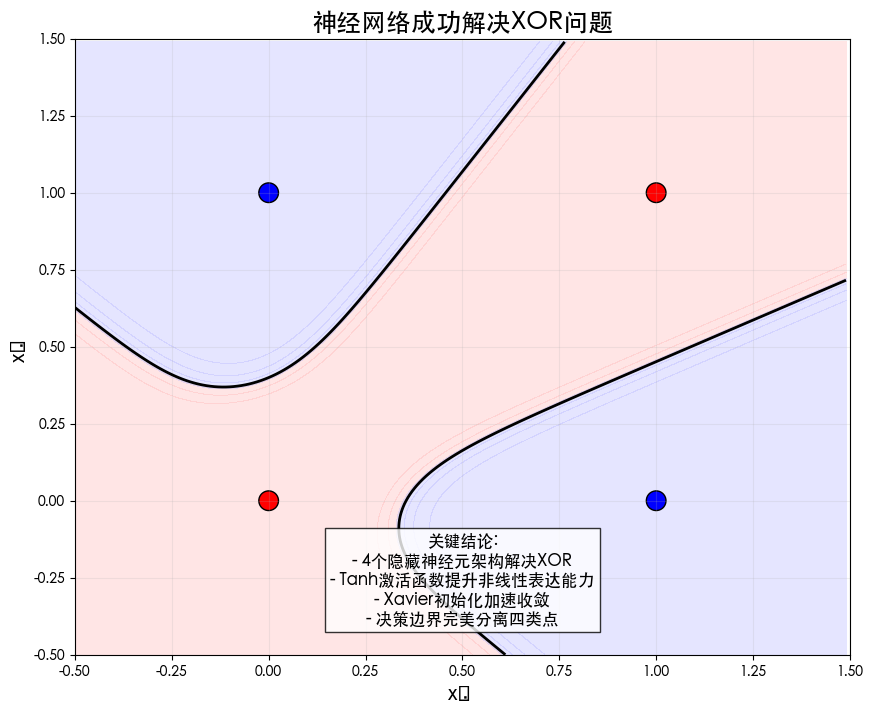

In [21]:
# 最终总结可视化
def plot_final_summary(X, y, params):
    """绘制最终总结图"""
    # 创建网格
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    resolution = 0.01
    xx, yy = np.meshgrid(np.arange(x_min, x_max, resolution),
                         np.arange(y_min, y_max, resolution))
    
    # 预测网格点
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z, _ = forward_pass(grid, params)
    Z = Z.reshape(xx.shape)
    
    # 创建颜色映射
    cmap_background = ListedColormap(['#FFAAAA', '#AAAAFF'])
    
    # 绘制决策边界
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_background)
    plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
    
    # 绘制训练数据点
    colors = ['red' if label == 0 else 'blue' for label in y]
    plt.scatter(X[:, 0], X[:, 1], s=200, c=colors, edgecolors='black')
    
    # 添加标题和标签
    plt.title('神经网络成功解决XOR问题', fontsize=18, fontweight='bold')
    plt.xlabel('x₁', fontsize=14)
    plt.ylabel('x₂', fontsize=14)
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.grid(True, alpha=0.2)
    
    # 添加解释性文本
    plt.text(0.5, -0.4, "关键结论:\n"
             "- 4个隐藏神经元架构解决XOR\n"
             "- Tanh激活函数提升非线性表达能力\n"
             "- Xavier初始化加速收敛\n"
             "- 决策边界完美分离四类点", 
             ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
    
    plt.show()

# 绘制最终总结图
plot_final_summary(X, y, params)